# Gráficas Test 1 ($T_n$)

Carga los CSV generados por `01_run_test1.ipynb` (o el script equivalente) y genera todas las gráficas en `results/figures/`. También permite mostrarlas inline para exploración.

Cambia `use_quick = True` para usar los datos quick si aún no has corrido el full.

In [2]:
# --- Setup ---
import sys, os
from pathlib import Path

ROOT = Path.cwd().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.plotting import (
    plot_type_i_error, plot_power_curves, plot_runtime,
    plot_power_vs_cost, plot_pvalue_distribution_h0,
)

print(f'Working dir: {Path.cwd()}')

Working dir: C:\Users\tejon\PycharmProjects\Proyecto2EstadisticaNP


## Cargar CSV

In [3]:
use_quick = False     # True: usa los CSVs '_quick'. False: usa los completos.

suffix = '_quick' if use_quick else ''
raw_csv = ROOT / 'results' / 'data' / f'tn_simulation_raw{suffix}.csv'
sum_csv = ROOT / 'results' / 'data' / f'tn_simulation_summary{suffix}.csv'

if not raw_csv.exists():
    raise FileNotFoundError(
        f'No se encontró {raw_csv}. Ejecuta primero `01_run_test1.ipynb`.'
    )

df = pd.read_csv(raw_csv)
summary = pd.read_csv(sum_csv)
print(f'Cargado: {raw_csv.name} ({len(df):,} filas)  /  {sum_csv.name} ({len(summary)} filas)')
print(f'Distribuciones: {sorted(df.dist.unique())}')
print(f'n: {sorted(df.n.unique())}, estimadores: {sorted(df.estimator.unique())}')

Cargado: tn_simulation_raw.csv (18,000 filas)  /  tn_simulation_summary.csv (60 filas)
Distribuciones: ['Cauchy(loc=2.0,scale=1.0)', 'Gamma(k=2.0,s=1.0)', 'Pareto(a=3.0,s=1.0)', 'Uniforme(1.0,3.0)', 'Weibull(k=1.5,s=1.0)']
n: [np.int64(20), np.int64(40), np.int64(80), np.int64(160)], estimadores: ['argmin', 'median', 'trimmed']


## Resumen pivotado

In [4]:
print('Tasa de rechazo:')
display(summary.pivot_table(index=['dist','estimator'], columns='n', values='reject_rate').round(3))
print('\nTiempo medio por test (s):')
display(summary.pivot_table(index=['dist','estimator'], columns='n', values='mean_time_s').round(3))

Tasa de rechazo:


n                                      20     40     80     160
dist                      estimator                            
Cauchy(loc=2.0,scale=1.0) argmin     0.030  0.023  0.053  0.050
                          median     0.027  0.017  0.020  0.030
                          trimmed    0.037  0.027  0.043  0.077
Gamma(k=2.0,s=1.0)        argmin     0.090  0.253  0.590  0.983
                          median     0.130  0.167  0.467  0.860
                          trimmed    0.027  0.140  0.543  0.963
Pareto(a=3.0,s=1.0)       argmin     0.290  0.683  0.980  1.000
                          median     0.290  0.620  0.890  1.000
                          trimmed    0.127  0.557  0.980  1.000
Uniforme(1.0,3.0)         argmin     0.017  0.033  0.017  0.033
                          median     0.087  0.070  0.083  0.073
                          trimmed    0.003  0.017  0.043  0.023
Weibull(k=1.5,s=1.0)      argmin     0.043  0.183  0.407  0.910
                          median     0.140  0.153  0.340  0.713
                          trimmed    0.027  0.083  0.360  0.880


Tiempo medio por test (s):


n                                      20     40     80     160
dist                      estimator                            
Cauchy(loc=2.0,scale=1.0) argmin     1.466  1.146  1.285  1.593
                          median     0.058  0.056  0.060  0.066
                          trimmed    0.207  0.201  0.205  0.219
Gamma(k=2.0,s=1.0)        argmin     0.993  1.052  1.319  1.469
                          median     0.055  0.058  0.066  0.066
                          trimmed    0.200  0.211  0.223  0.213
Pareto(a=3.0,s=1.0)       argmin     0.945  1.045  1.148  1.497
                          median     0.055  0.058  0.064  0.073
                          trimmed    0.204  0.205  0.219  0.219
Uniforme(1.0,3.0)         argmin     1.723  2.305  2.304  2.818
                          median     0.084  0.122  0.139  0.121
                          trimmed    0.410  0.566  0.355  0.384
Weibull(k=1.5,s=1.0)      argmin     0.942  0.992  1.110  1.375
                          median     0.055  0.056  0.060  0.066
                          trimmed    0.201  0.203  0.206  0.213

## Generar todas las figuras

Se guardan en `results/figures/`. Cada celda muestra la figura inline.

In [5]:
fig_dir = ROOT / 'results' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
alpha = 0.05

def show(path):
    if path is not None and Path(path).exists():
        display(Image(filename=str(path)))
    else:
        print(f'(sin imagen)')

### Error Tipo I bajo H₀

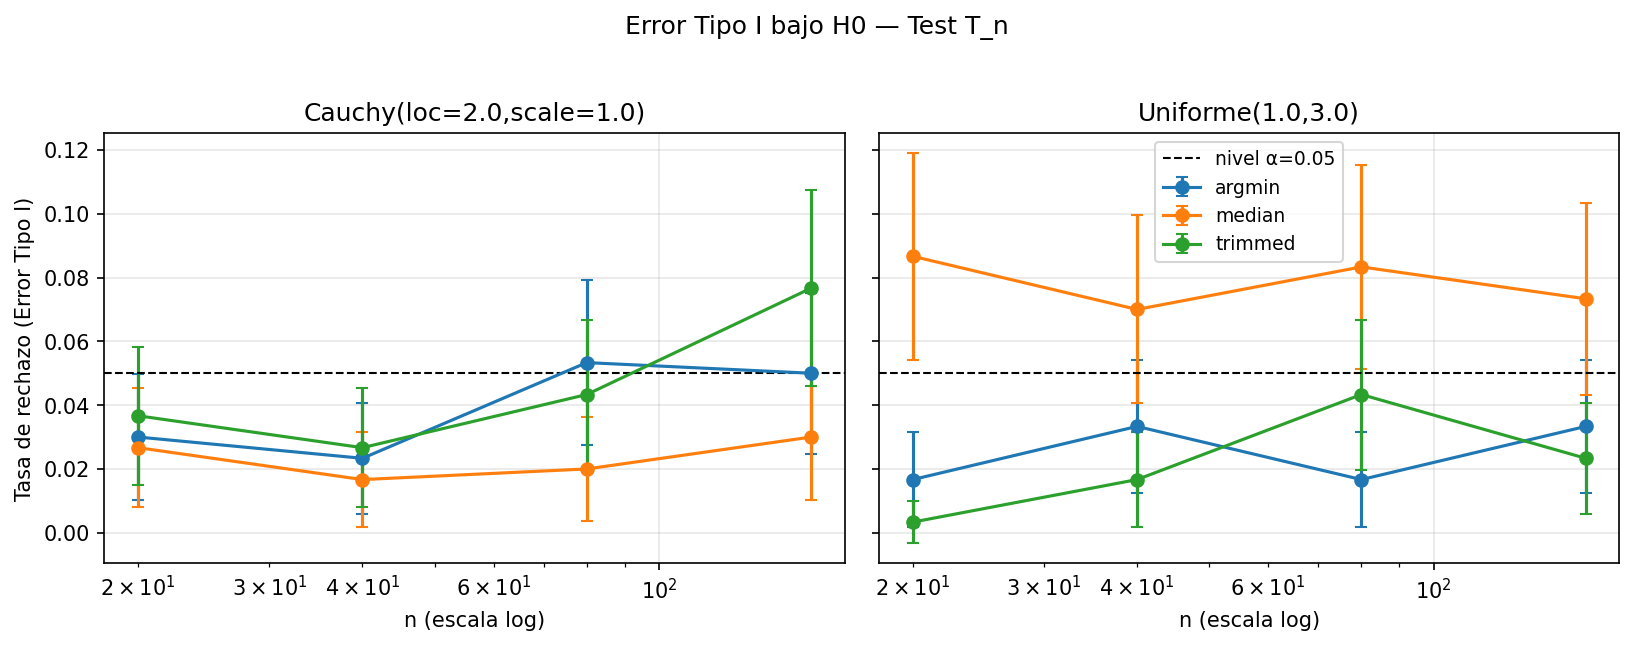

In [6]:
show(plot_type_i_error(summary, alpha=alpha, outdir=fig_dir))

### Curvas de potencia bajo Hₐ

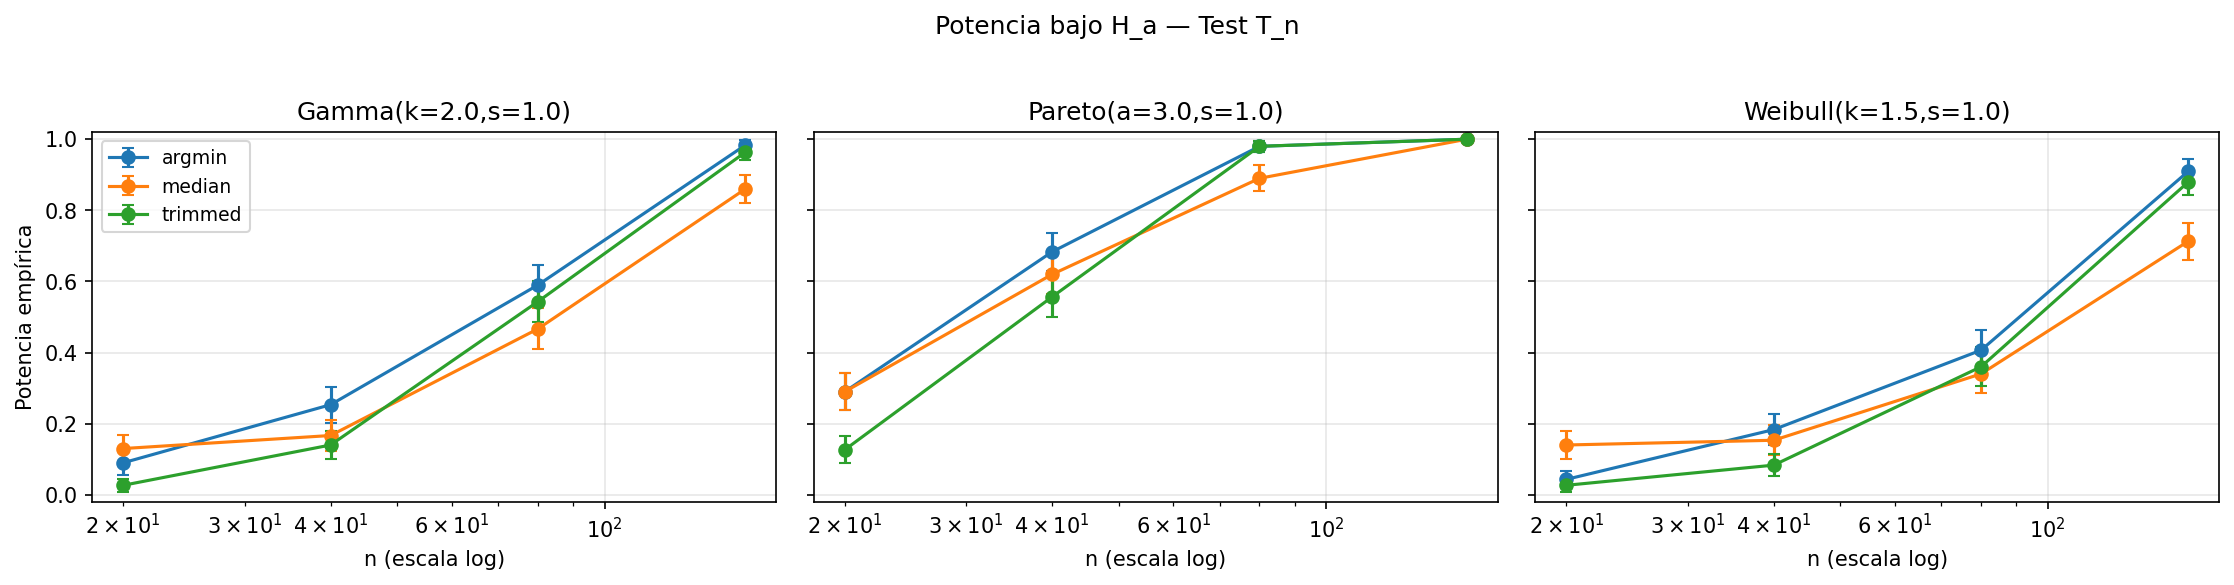

In [7]:
show(plot_power_curves(summary, outdir=fig_dir))

### Tiempo de ejecución vs n

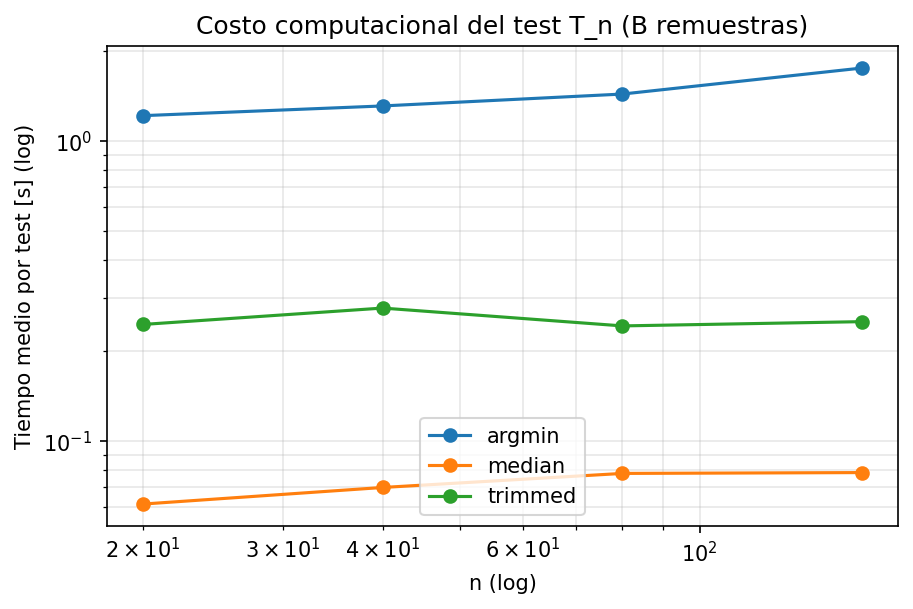

In [8]:
show(plot_runtime(summary, outdir=fig_dir))

### Costo computacional vs potencia

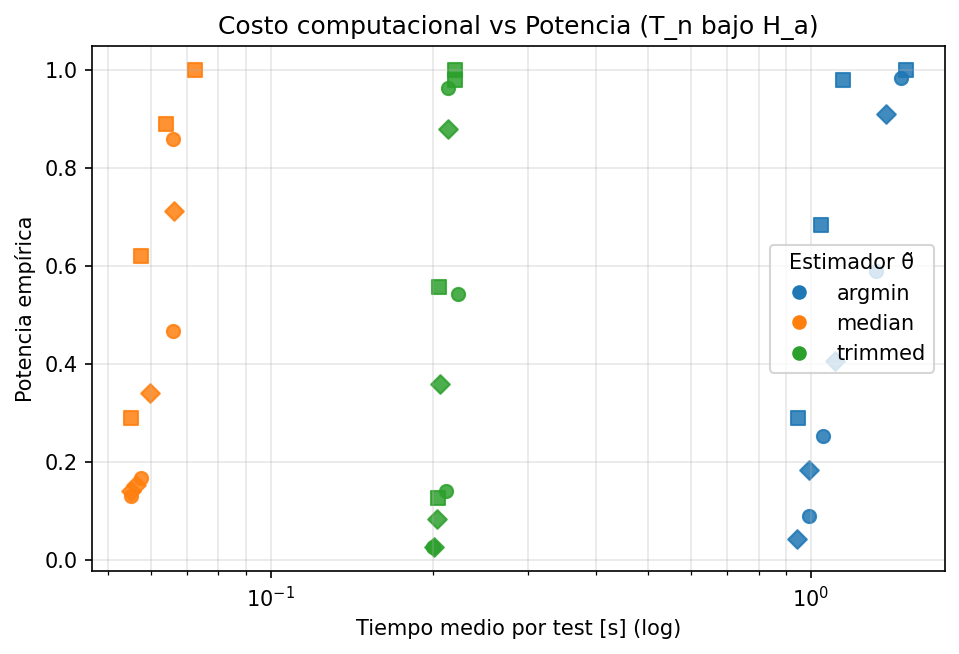

In [9]:
show(plot_power_vs_cost(summary, outdir=fig_dir))

### Distribución del p-valor bajo H₀ (sanity check: debería ser ~U(0,1))

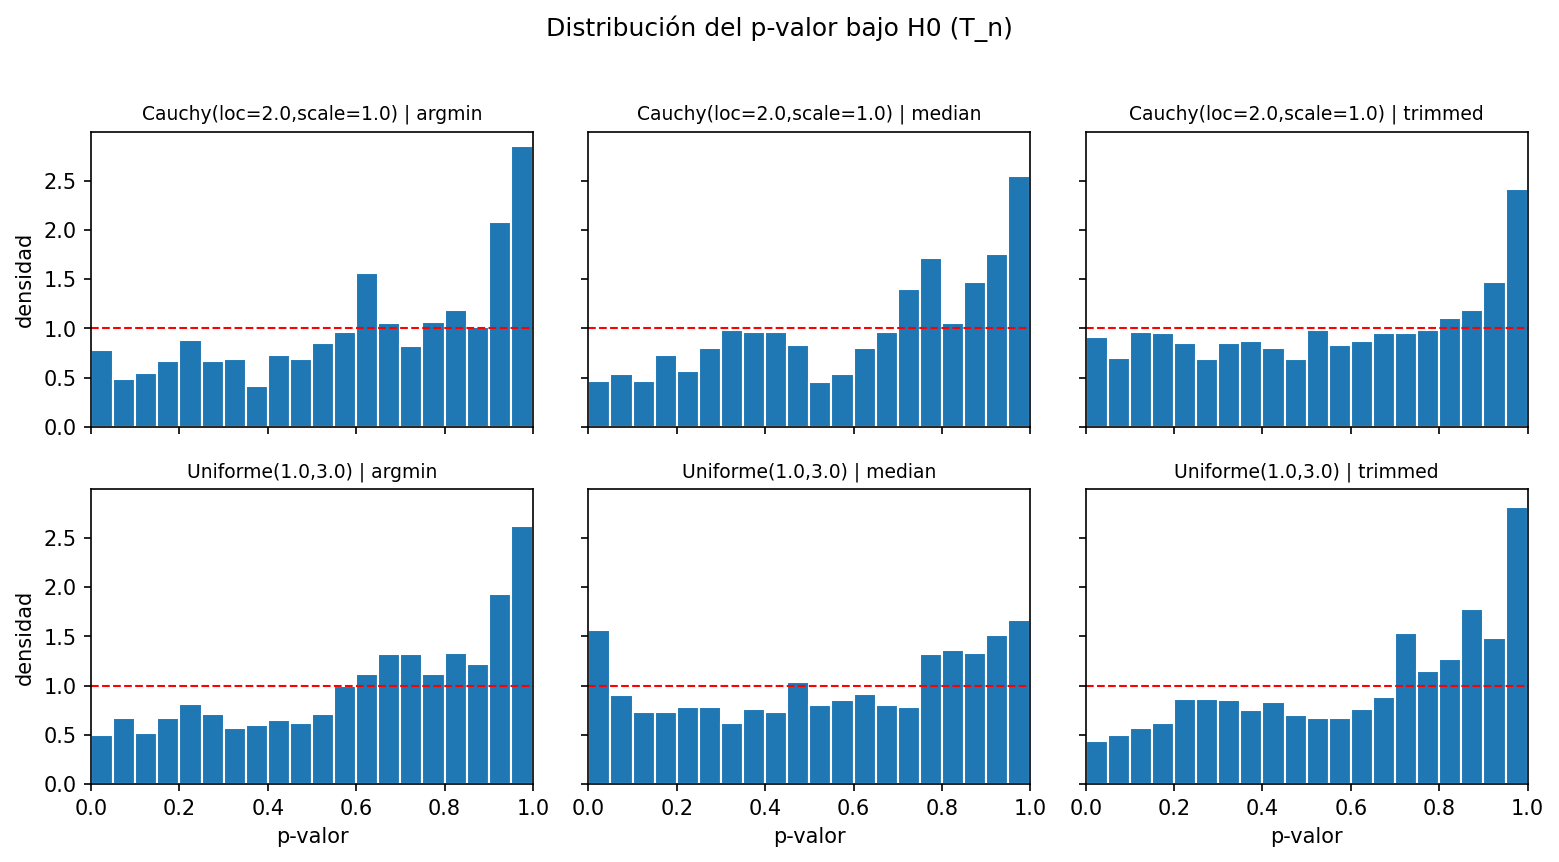

In [10]:
show(plot_pvalue_distribution_h0(df, outdir=fig_dir))

## Exploración interactiva

Plantilla para hacer tus propios cortes/gráficas.

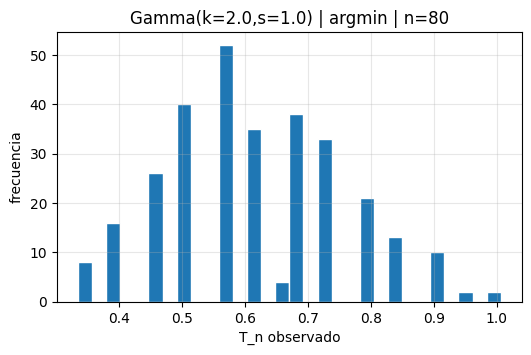

In [11]:
# Ejemplo: histograma del estadístico T_n para una celda específica
dist = 'Gamma(k=2.0,s=1.0)'
estimator = 'argmin'
n = 80

sub = df[(df['dist']==dist) & (df['estimator']==estimator) & (df['n']==n)]
fig, ax = plt.subplots(figsize=(6,3.5))
ax.hist(sub['statistic'], bins=30, color='C0', edgecolor='white')
ax.set_xlabel('T_n observado')
ax.set_ylabel('frecuencia')
ax.set_title(f'{dist} | {estimator} | n={n}')
ax.grid(True, alpha=0.3)
plt.show()